# Week 9: Gradient Boosting

This notebook applies gradient boosting models to the Diabetes Health Indicators and Alzheimer's disease datasets. The analysis will examine how learning rate, number of estimators, tree depth, and regularization affect model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the diabetes dataset
df_diabetes = pd.read_csv(
    "diabetes_012_health_indicators_BRFSS2015.csv"
)

# Load the Alzheimer's dataset
df_alzheimers = pd.read_csv(
    "alzheimers_disease_data.csv"
)

# Remove the non-predictive text column
df_alzheimers = df_alzheimers.drop(
    columns=["DoctorInCharge"]
)

print("Diabetes dataset shape:", df_diabetes.shape)
print("Alzheimer's dataset shape:", df_alzheimers.shape)

Diabetes dataset shape: (253680, 22)
Alzheimer's dataset shape: (2149, 34)


In [2]:
df_diabetes.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
df_alzheimers.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,6.045039,0,0,0.014691,0,0,1,1,0,0


In [5]:
print("Diabetes missing values:", df_diabetes.isnull().sum().sum())
print("Alzheimer's missing values:", df_alzheimers.isnull().sum().sum())

print("\nDiabetes target values:")
print(df_diabetes["Diabetes_012"].value_counts().sort_index())

print("\nAlzheimer's target values:")
print(df_alzheimers["Diagnosis"].value_counts().sort_index())

Diabetes missing values: 0
Alzheimer's missing values: 0

Diabetes target values:
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

Alzheimer's target values:
Diagnosis
0    1389
1     760
Name: count, dtype: int64


In [6]:
# Diabetes features and target
X_diabetes = df_diabetes.drop(columns=["Diabetes_012"])
y_diabetes = df_diabetes["Diabetes_012"]

# Alzheimer's features and target
X_alzheimers = df_alzheimers.drop(
    columns=["Diagnosis", "PatientID"]
)
y_alzheimers = df_alzheimers["Diagnosis"]

print("Diabetes features shape:", X_diabetes.shape)
print("Diabetes target shape:", y_diabetes.shape)

print("\nAlzheimer's features shape:", X_alzheimers.shape)
print("Alzheimer's target shape:", y_alzheimers.shape)

Diabetes features shape: (253680, 21)
Diabetes target shape: (253680,)

Alzheimer's features shape: (2149, 32)
Alzheimer's target shape: (2149,)


In [7]:
from sklearn.model_selection import train_test_split

# Diabetes train/test split
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.2,
    random_state=42
)

# Alzheimer's train/test split
X_train_alzheimers, X_test_alzheimers, y_train_alzheimers, y_test_alzheimers = train_test_split(
    X_alzheimers,
    y_alzheimers,
    test_size=0.2,
    random_state=42
)

print("Diabetes training shape:", X_train_diabetes.shape)
print("Diabetes testing shape:", X_test_diabetes.shape)

print("\nAlzheimer's training shape:", X_train_alzheimers.shape)
print("Alzheimer's testing shape:", X_test_alzheimers.shape)

Diabetes training shape: (202944, 21)
Diabetes testing shape: (50736, 21)

Alzheimer's training shape: (1719, 32)
Alzheimer's testing shape: (430, 32)


## Baseline Gradient Boosting Models

Gradient boosting builds decision trees sequentially. Each new tree attempts to correct errors made by the previous trees. Unlike random forest, where trees are trained independently, the trees in gradient boosting depend on the performance of the earlier learners.

Because the diabetes and Alzheimer's targets represent diagnostic categories, gradient boosting classification models will be used.

In [8]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
# Baseline Gradient Boosting model for Diabetes
gb_diabetes = GradientBoostingClassifier(random_state=42)
gb_diabetes.fit(X_train_diabetes, y_train_diabetes)

# Baseline Gradient Boosting model for Alzheimer's
gb_alzheimers = GradientBoostingClassifier(random_state=42)
gb_alzheimers.fit(X_train_alzheimers, y_train_alzheimers)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [10]:
print("Diabetes model fitted:", hasattr(gb_diabetes, "classes_"))
print("Diabetes estimators:", gb_diabetes.n_estimators_)
print("Diabetes features:", gb_diabetes.n_features_in_)

Diabetes model fitted: True
Diabetes estimators: 100
Diabetes features: 21


In [11]:
# Diabetes predictions
y_pred_diabetes = gb_diabetes.predict(X_test_diabetes)

# Alzheimer's predictions
y_pred_alzheimers = gb_alzheimers.predict(X_test_alzheimers)

# Baseline accuracy
diabetes_accuracy = accuracy_score(
    y_test_diabetes,
    y_pred_diabetes
)

alzheimers_accuracy = accuracy_score(
    y_test_alzheimers,
    y_pred_alzheimers
)

print("Diabetes Gradient Boosting Accuracy:", diabetes_accuracy)
print("Alzheimer's Gradient Boosting Accuracy:", alzheimers_accuracy)

Diabetes Gradient Boosting Accuracy: 0.8508554083885209
Alzheimer's Gradient Boosting Accuracy: 0.958139534883721


In [12]:
print("Diabetes Classification Report:")
print(classification_report(
    y_test_diabetes,
    y_pred_diabetes,
    zero_division=0
))

print("\nAlzheimer's Classification Report:")
print(classification_report(
    y_test_alzheimers,
    y_pred_alzheimers,
    zero_division=0
))

Diabetes Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92     42795
         1.0       0.00      0.00      0.00       944
         2.0       0.55      0.20      0.30      6997

    accuracy                           0.85     50736
   macro avg       0.47      0.39      0.41     50736
weighted avg       0.81      0.85      0.82     50736


Alzheimer's Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       277
           1       0.96      0.92      0.94       153

    accuracy                           0.96       430
   macro avg       0.96      0.95      0.95       430
weighted avg       0.96      0.96      0.96       430



### Baseline Model Interpretation

The baseline gradient boosting model achieved an accuracy of approximately 85.1% on the diabetes dataset. However, the classification report shows that this result is strongly influenced by the majority class. The model correctly identified most non-diabetic observations but failed to identify any prediabetic observations and detected only a small portion of diabetic observations. Therefore, the high overall accuracy does not mean that the model performs equally well across all three classes.

The Alzheimer's model performed much better across both classes. It achieved approximately 95.8% accuracy, with strong precision, recall, and F1-scores for both patients without and with an Alzheimer's diagnosis. This suggests that the clinical features in the Alzheimer's dataset provide clearer separation between the two diagnostic groups.

In [13]:
learning_rates = [0.01, 0.05, 0.10, 0.20]

diabetes_results = []
alzheimers_results = []

for lr in learning_rates:

    # Diabetes model
    gb_diabetes = GradientBoostingClassifier(
        learning_rate=lr,
        random_state=42
    )

    gb_diabetes.fit(X_train_diabetes, y_train_diabetes)

    diabetes_pred = gb_diabetes.predict(X_test_diabetes)

    diabetes_results.append({
        "Learning Rate": lr,
        "Accuracy": accuracy_score(y_test_diabetes, diabetes_pred)
    })


    # Alzheimer's model
    gb_alzheimers = GradientBoostingClassifier(
        learning_rate=lr,
        random_state=42
    )

    gb_alzheimers.fit(X_train_alzheimers, y_train_alzheimers)

    alzheimers_pred = gb_alzheimers.predict(X_test_alzheimers)

    alzheimers_results.append({
        "Learning Rate": lr,
        "Accuracy": accuracy_score(y_test_alzheimers, alzheimers_pred)
    })

In [14]:
pd.DataFrame(diabetes_results)

,Learning Rate,Accuracy
0,0.01,0.843484
1,0.05,0.851033
2,0.10,0.850855
3,0.20,0.850895


In [15]:
pd.DataFrame(alzheimers_results)

,Learning Rate,Accuracy
0,0.01,0.895349
1,0.05,0.958140
2,0.10,0.958140
3,0.20,0.944186


### Learning Rate Interpretation

The learning rate had little effect on diabetes accuracy once it reached 0.05. A learning rate of 0.01 produced lower accuracy, suggesting that the model learned too slowly when limited to 100 estimators. Learning rates of 0.05, 0.10, and 0.20 produced nearly identical results.

The Alzheimer's model was more sensitive to the learning rate. Rates of 0.05 and 0.10 produced the highest accuracy, while 0.01 appeared to underfit and 0.20 slightly reduced performance. This shows the trade-off between making gradual corrections and updating the model too aggressively.

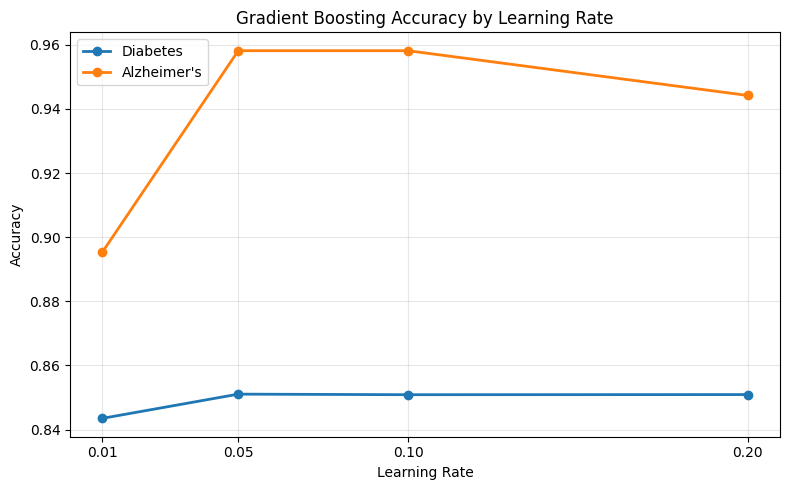

In [18]:
plt.figure(figsize=(8,5))

plt.plot(
    diabetes_lr_df["Learning Rate"],
    diabetes_lr_df["Accuracy"],
    marker="o",
    linewidth=2,
    label="Diabetes"
)

plt.plot(
    alzheimers_lr_df["Learning Rate"],
    alzheimers_lr_df["Accuracy"],
    marker="o",
    linewidth=2,
    label="Alzheimer's"
)

plt.xticks(learning_rates)

plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting Accuracy by Learning Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Number of Estimators

The number of estimators controls how many weak learners are added to the gradient boosting model. Too few estimators may cause underfitting, while too many can increase complexity and training time without improving test performance.

In [19]:
estimator_values = [25, 50, 100, 200]

diabetes_estimator_results = []
alzheimers_estimator_results = []

for n in estimator_values:

    # Diabetes model
    gb_diabetes_n = GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=n,
        random_state=42
    )

    gb_diabetes_n.fit(
        X_train_diabetes,
        y_train_diabetes
    )

    diabetes_pred_n = gb_diabetes_n.predict(
        X_test_diabetes
    )

    diabetes_estimator_results.append({
        "Estimators": n,
        "Accuracy": accuracy_score(
            y_test_diabetes,
            diabetes_pred_n
        )
    })

    # Alzheimer's model
    gb_alzheimers_n = GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=n,
        random_state=42
    )

    gb_alzheimers_n.fit(
        X_train_alzheimers,
        y_train_alzheimers
    )

    alzheimers_pred_n = gb_alzheimers_n.predict(
        X_test_alzheimers
    )

    alzheimers_estimator_results.append({
        "Estimators": n,
        "Accuracy": accuracy_score(
            y_test_alzheimers,
            alzheimers_pred_n
        )
    })

print("Finished")

Finished


In [20]:
diabetes_estimator_df = pd.DataFrame(diabetes_estimator_results)
alzheimers_estimator_df = pd.DataFrame(alzheimers_estimator_results)

diabetes_estimator_df

,Estimators,Accuracy
0,25,0.844391
1,50,0.849693
2,100,0.851033
3,200,0.850579


In [21]:
alzheimers_estimator_df

,Estimators,Accuracy
0,25,0.895349
1,50,0.927907
2,100,0.958140
3,200,0.955814


### Number of Estimators Interpretation

Increasing the number of estimators improved performance for both datasets up to 100 trees. The diabetes model increased from approximately 84.4% accuracy with 25 estimators to 85.1% with 100 estimators. Increasing the model to 200 estimators did not improve performance and caused a slight decline.

The Alzheimer's model showed a larger improvement, increasing from approximately 89.5% accuracy with 25 estimators to 95.8% with 100 estimators. Accuracy decreased slightly with 200 estimators. These results suggest that too few estimators caused underfitting, while adding trees beyond 100 increased complexity without improving generalization.

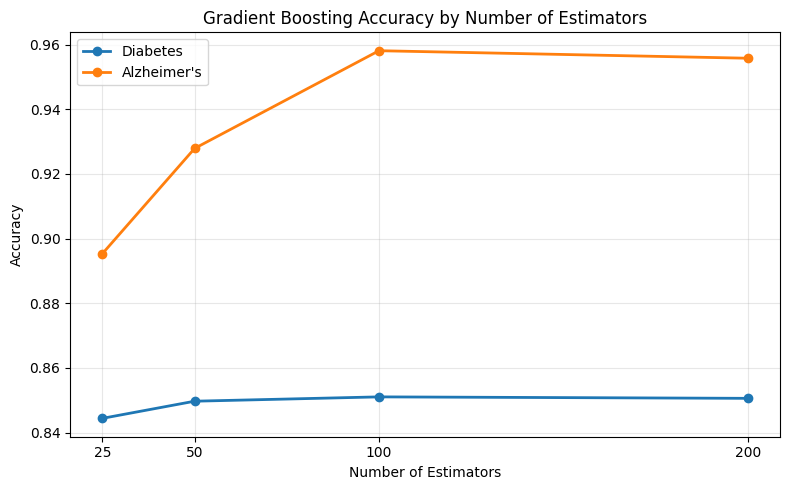

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    diabetes_estimator_df["Estimators"],
    diabetes_estimator_df["Accuracy"],
    marker="o",
    linewidth=2,
    label="Diabetes"
)

plt.plot(
    alzheimers_estimator_df["Estimators"],
    alzheimers_estimator_df["Accuracy"],
    marker="o",
    linewidth=2,
    label="Alzheimer's"
)

plt.xticks(estimator_values)
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting Accuracy by Number of Estimators")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Tree Depth

The maximum tree depth controls the complexity of each weak learner in the gradient boosting model. Shallow trees may underfit by failing to capture complex relationships, while deeper trees may overfit by learning noise in the training data.

In [23]:
depth_values = [1, 2, 3, 5]

diabetes_depth_results = []
alzheimers_depth_results = []

for depth in depth_values:

    # Diabetes
    gb_diabetes_depth = GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    gb_diabetes_depth.fit(
        X_train_diabetes,
        y_train_diabetes
    )

    diabetes_pred = gb_diabetes_depth.predict(X_test_diabetes)

    diabetes_depth_results.append({
        "Max Depth": depth,
        "Accuracy": accuracy_score(
            y_test_diabetes,
            diabetes_pred
        )
    })

    # Alzheimer's
    gb_alzheimers_depth = GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    gb_alzheimers_depth.fit(
        X_train_alzheimers,
        y_train_alzheimers
    )

    alzheimers_pred = gb_alzheimers_depth.predict(X_test_alzheimers)

    alzheimers_depth_results.append({
        "Max Depth": depth,
        "Accuracy": accuracy_score(
            y_test_alzheimers,
            alzheimers_pred
        )
    })

print("Finished")

Finished


In [24]:
diabetes_depth_df = pd.DataFrame(diabetes_depth_results)
alzheimers_depth_df = pd.DataFrame(alzheimers_depth_results)

diabetes_depth_df

,Max Depth,Accuracy
0,1,0.847800
1,2,0.850244
2,3,0.851033
3,5,0.851151


In [25]:
alzheimers_depth_df

,Max Depth,Accuracy
0,1,0.883721
1,2,0.960465
2,3,0.958140
3,5,0.948837


### Tree Depth Interpretation

Increasing tree depth had only a small effect on the diabetes model. Accuracy improved from approximately 84.8% at depth 1 to 85.1% at depth 5, but the improvement after depth 3 was minimal. This suggests that deeper weak learners added complexity without providing a meaningful increase in performance.

The Alzheimer's model was more sensitive to tree depth. A depth of 1 appeared to underfit, while depth 2 achieved the highest accuracy at approximately 96.0%. Accuracy declined as depth increased to 3 and 5, suggesting that the deeper weak learners may have begun fitting noise in the training data rather than improving generalization.

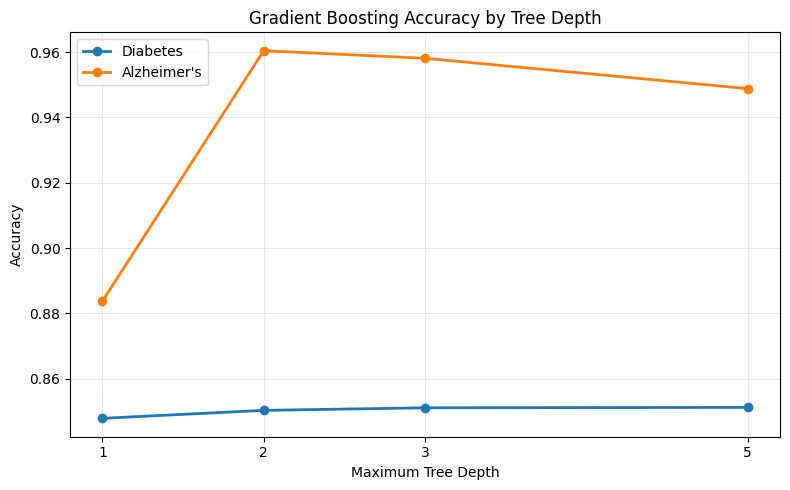

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    diabetes_depth_df["Max Depth"],
    diabetes_depth_df["Accuracy"],
    marker="o",
    linewidth=2,
    label="Diabetes"
)

plt.plot(
    alzheimers_depth_df["Max Depth"],
    alzheimers_depth_df["Accuracy"],
    marker="o",
    linewidth=2,
    label="Alzheimer's"
)

plt.xticks(depth_values)
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting Accuracy by Tree Depth")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Regularization (Subsampling)

Gradient boosting can be regularized by training each weak learner on only a subset of the training data. Using a subsample smaller than 1.0 introduces randomness, which may reduce overfitting while maintaining good predictive performance.

In [27]:
subsample_values = [0.6, 0.8, 1.0]

diabetes_regularization_results = []
alzheimers_regularization_results = []

for s in subsample_values:

    # Diabetes
    gb_diabetes_reg = GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=100,
        max_depth=2,
        subsample=s,
        random_state=42
    )

    gb_diabetes_reg.fit(
        X_train_diabetes,
        y_train_diabetes
    )

    diabetes_pred = gb_diabetes_reg.predict(X_test_diabetes)

    diabetes_regularization_results.append({
        "Subsample": s,
        "Accuracy": accuracy_score(
            y_test_diabetes,
            diabetes_pred
        )
    })


    # Alzheimer's
    gb_alzheimers_reg = GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=100,
        max_depth=2,
        subsample=s,
        random_state=42
    )

    gb_alzheimers_reg.fit(
        X_train_alzheimers,
        y_train_alzheimers
    )

    alzheimers_pred = gb_alzheimers_reg.predict(X_test_alzheimers)

    alzheimers_regularization_results.append({
        "Subsample": s,
        "Accuracy": accuracy_score(
            y_test_alzheimers,
            alzheimers_pred
        )
    })

print("Finished")

Finished


In [28]:
diabetes_regularization_df = pd.DataFrame(
    diabetes_regularization_results
)

alzheimers_regularization_df = pd.DataFrame(
    alzheimers_regularization_results
)

diabetes_regularization_df

,Subsample,Accuracy
0,0.6,0.850520
1,0.8,0.850382
2,1.0,0.850244


In [29]:
alzheimers_regularization_df

,Subsample,Accuracy
0,0.6,0.958140
1,0.8,0.958140
2,1.0,0.960465


### Regularization Interpretation

Subsampling had only a small effect on both datasets. For diabetes, using 60% or 80% of the training observations for each weak learner produced nearly the same accuracy as using the full training set, with a very slight improvement at a subsample of 0.6. This suggests that subsampling reduced model complexity without sacrificing predictive performance.

For Alzheimer's, the full-sample model achieved the highest accuracy, although the difference was small. The subsampled models still performed well, but the results suggest that additional regularization was not necessary for the depth-2 model. Overall, the impact of subsampling depended on the dataset and did not automatically improve performance.

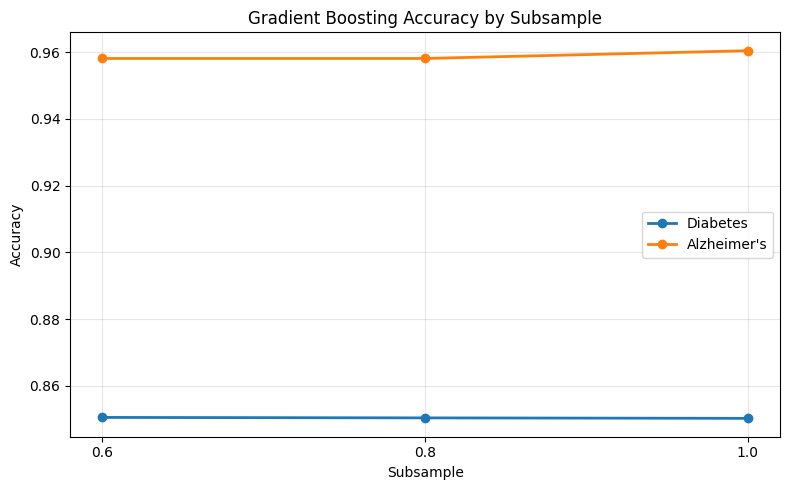

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    diabetes_regularization_df["Subsample"],
    diabetes_regularization_df["Accuracy"],
    marker="o",
    linewidth=2,
    label="Diabetes"
)

plt.plot(
    alzheimers_regularization_df["Subsample"],
    alzheimers_regularization_df["Accuracy"],
    marker="o",
    linewidth=2,
    label="Alzheimer's"
)

plt.xticks(subsample_values)
plt.xlabel("Subsample")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting Accuracy by Subsample")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

Gradient boosting produced strong predictive performance on both healthcare datasets while demonstrating the importance of hyperparameter tuning. The diabetes model achieved relatively consistent performance across different learning rates, tree depths, and subsampling values, suggesting that the model was robust and less sensitive to these parameters. In contrast, the Alzheimer's model showed greater sensitivity, with learning rate, number of estimators, and tree depth having a more noticeable impact on accuracy. The best results were obtained using moderate learning rates, approximately 100 estimators, and relatively shallow trees, while increasing model complexity beyond these values provided little or no improvement. Overall, these experiments demonstrated that carefully selecting gradient boosting hyperparameters can improve model performance while avoiding unnecessary complexity, reinforcing the balance between model accuracy and generalization.